# Bitcoin Persistence-Enhanced Log-Return LSTM

## Role
This notebook evaluates the project's final supervised recurrent Bitcoin model: an LSTM trained on log returns and reconstructed around the most recently observed price, tested against the transparent classical benchmark floor established in Notebook 02.

## Inputs
The canonical Bitcoin daily Close series (same pipeline as Notebooks 01-02). The training-only inputs actually used during generation (verified from the repository's preserved generation code, not rerun here): a 30-day window of scaled daily log returns, with the return scaler fit strictly on training-period returns.

## Outputs
The authoritative frozen forecast artifact `results/persistence_enhanced_lstm_forecast.csv` (verified present: one `Persistence_Enhanced_LSTM` column, 1,061 rows), consumed here for artifact-derived metrics, plots, and a reproducibility record. This notebook does not retrain the model or overwrite that artifact during normal execution.

## Depends On
`01_Bitcoin_Data_EDA.ipynb`
`02_Bitcoin_Classical_Baselines.ipynb`

## Authoritative Status
`AUTHORITATIVE SUPERVISED NEURAL MODEL`

## What This Notebook Does Not Do
It does not evaluate Chronos, TimesFM, or the Transformer model, and it does not calculate final Trust Scores, run cross-domain analysis, or establish statistical significance. Those are handled in later notebooks.

## 1. Objective and Research Question

> Does a supervised recurrent model trained on Bitcoin log returns, with persistence-anchored price reconstruction, improve on the transparent classical forecasting floor established in Notebook 02?

This question matters because Notebook 02 shows that persistence and simple statistical models are difficult to beat under the fair rolling one-step protocol: none of the five classical systems tested there significantly improves on Naive, and one (the 7-Day Moving Average) is significantly worse under Holm-adjusted testing. This notebook tests whether nonlinear recurrent sequence modelling adds useful predictive signal beyond that floor.

The LSTM is not assumed to win. The outcome may legitimately show that added model complexity does not improve accuracy - that is itself a meaningful, reportable result for this project's broader trustworthiness question.

## 2. Setup

Standard project-root discovery and the repository's existing Bitcoin pipeline utilities - no data-loading or metric logic is duplicated here. This notebook loads the frozen forecast artifact; it does not import TensorFlow or any neural-network library during normal execution.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.bitcoin_pipeline import *

RUN_GENERATION = False
PROMOTE_TO_AUTHORITATIVE = False
RUN_TRAINING = False  # Safety flag: this notebook is artifact-driven and does not retrain the PE-LSTM.

# 3. Data and Method

In [2]:
# Load once: canonical target/split and the frozen validated forecast vectors.
_, target = load_bitcoin_target(ROOT)
train, test = canonical_split(target)
validated = load_validated_forecasts(ROOT)
validated[['Actual', 'Persistence_Enhanced_LSTM']].tail()

,Actual,Persistence_Enhanced_LSTM
Timestamp,,
2026-07-03 00:00:00+00:00,62522.46,61183.922036
2026-07-04 00:00:00+00:00,63086.18,62283.337122
2026-07-05 00:00:00+00:00,63587.06,62889.997554
2026-07-06 00:00:00+00:00,64000.10,63426.891045
2026-07-07 00:00:00+00:00,63902.77,63864.945065


## 3.1 Target Representation

The network is trained on daily log returns, not raw price levels:

`r_t = log(P_t / P_(t-1))`

This choice is motivated directly by Notebook 01's stationarity evidence: daily Close is strongly non-stationary in levels (ADF fails to reject a unit root; KPSS rejects stationarity), while log returns are much closer to stationary (ADF strongly rejects the unit-root null; KPSS does not reject stationarity at 5%, albeit narrowly). Modelling returns avoids training a sequence model directly on a series whose scale has grown by roughly four orders of magnitude over the observed history. The forecast is nonetheless reconstructed back to a price using the most recently observed actual Close (Section 3.3) - the model is never asked to predict on the raw non-stationary price scale, but its output is still anchored to real, currently-available price information.

**Scaling** (verified from the repository's preserved PE-LSTM generation code): a `MinMaxScaler(feature_range=(-1, 1))` is fit **only** on the training-period log returns. The fitted scaler is then applied (`.transform`, never re-fit) to the test-adjacent return context used to build test-period input sequences. No validation or test observation ever enters scaler fitting.

## 3.2 Architecture

Every field below is read directly from the verified generation code (the `build_delta_lstm` function and its `model.fit` call); nothing is guessed, and fields not explicitly set in that code are labelled as framework defaults rather than invented.

In [3]:
architecture_table = pd.DataFrame({
    'Value': [
        '30 daily log returns',
        '1 (univariate log return)',
        1,
        32,
        '1 Dense layer, 1 unit (linear output)',
        'Not used (no Dropout layer in the implementation)',
        'Not explicitly set in code (Keras LSTM default: tanh activation, sigmoid recurrent activation)',
        'Mean squared error (mse)',
        'Adam',
        'Not explicitly configured / framework default (Keras Adam default learning rate)',
        32,
        20,
        "Yes: EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)",
        'validation_split=0.1 inside model.fit (chronologically most-recent 10% of the training sequence set, since shuffle=False)',
        False,
        42,
    ],
}, index=[
    'Input window', 'Input features', 'Number of LSTM layers', 'Units per LSTM layer',
    'Dense/output layers', 'Dropout', 'Activation(s)', 'Loss function', 'Optimizer',
    'Learning rate', 'Batch size', 'Maximum epochs', 'Early stopping', 'Validation design',
    'Shuffle', 'Random seed',
])
architecture_table

,Value
Input window,30 daily log returns
Input features,1 (univariate log return)
Number of LSTM layers,1
Units per LSTM layer,32
Dense/output layers,"1 Dense layer, 1 unit (linear output)"
Dropout,Not used (no Dropout layer in the implementation)
Activation(s),Not explicitly set in code (Keras LSTM default...
Loss function,Mean squared error (mse)
Optimizer,Adam
Learning rate,Not explicitly configured / framework default ...


## 3.3 Persistence-Enhancement Design

This is the distinctive methodological choice in this model. The network predicts a scaled next-day log return, `r_hat_t`; the forecast price is then reconstructed as:

`P_hat_t = P_(t-1) * exp(r_hat_t)`

where `P_(t-1)` is the previously observed **actual** Close (verified from the generation code: the reconstruction uses `target.shift(1)` reindexed to the test dates).

This means the network models the *movement* away from the previous price rather than the full raw price level, and the reconstruction is anchored to the latest observed actual price rather than to a prior forecast. This is **not** persistence "added after seeing the target": `P_(t-1)` is strictly prior information, already available at the forecast origin for date `t`, exactly like every classical model in Notebook 02. The design preserves the strong persistence structure identified in Notebook 02 while giving the LSTM room to model deviations - the predicted return - from pure persistence.

## 3.4 Training and Validation Protocol

In [4]:
training_protocol = pd.DataFrame({
    'Detail': [
        f"{train.index.min().date()} to {train.index.max().date()} ({len(train)} days)",
        'validation_split=0.1 inside model.fit, applied to training sequences only (shuffle=False, so this is the chronologically most-recent 10% of the training set, never test data)',
        f"{test.index.min().date()} to {test.index.max().date()} ({len(test)} days)",
        '30 days of prior log returns',
        'Fit only on training-period log returns; applied (never re-fit) to the test-adjacent context',
        42,
        'Yes: single-threaded op determinism (intra/inter-op parallelism pinned to 1, TensorFlow op determinism enabled) plus seeded layer initializers',
        False,
        "Yes: EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)",
        'restore_best_weights=True (best validation-loss epoch restored, not necessarily the final epoch)',
        'Yes -- the final test period is never used for scaler fitting, hyperparameter selection, early stopping, or training',
    ],
}, index=[
    'Chronological training period', 'Validation construction', 'Final test period',
    'Input window length', 'Scaler fitting boundary', 'Seed', 'Deterministic TensorFlow setting',
    'shuffle', 'Early stopping', 'Checkpoint/model selection method', 'Final-test isolation',
])
training_protocol

,Detail
Chronological training period,2012-01-01 to 2023-08-11 (4241 days)
Validation construction,"validation_split=0.1 inside model.fit, applied..."
Final test period,2023-08-12 to 2026-07-07 (1061 days)
Input window length,30 days of prior log returns
Scaler fitting boundary,Fit only on training-period log returns; appli...
Seed,42
Deterministic TensorFlow setting,Yes: single-threaded op determinism (intra/int...
shuffle,False
Early stopping,"Yes: EarlyStopping(monitor='val_loss', patienc..."
Checkpoint/model selection method,restore_best_weights=True (best validation-los...


Some hyperparameters (lookback length, LSTM units, batch size, epoch budget) are fixed choices from the repository's implementation rather than the result of a documented systematic search; this is stated plainly rather than implied to be tuned (see Limitations, Section 8).

## 3.5 Training Diagnostics

Epoch-by-epoch training was not preserved for the authoritative PE-LSTM run: the preserved generation code captures a training-history object from `model.fit(...)`, but never plots, prints, or saves its per-epoch loss values anywhere in the notebook or in any file tracked by this repository. This was checked directly against the historical generation commit, not assumed.

In [5]:
training_diagnostics = pd.DataFrame({
    'Status': ['No', 'No', 'Yes', 'Yes', 'No'],
}, index=[
    'Epoch-level training loss preserved',
    'Epoch-level validation loss preserved',
    'Final forecast vector preserved',
    'Deterministic configuration preserved',
    'Independent rerun vectors preserved',
])
training_diagnostics

,Status
Epoch-level training loss preserved,No
Epoch-level validation loss preserved,No
Final forecast vector preserved,Yes
Deterministic configuration preserved,Yes
Independent rerun vectors preserved,No


> Epoch-level training history was not preserved as an authoritative artifact, so a retrospective training-loss curve is not fabricated here.

# 4. Results

## 4.1 Forecast Performance

In [6]:
pe_lstm_metrics = metric_table(
    validated.Actual,
    {'Persistence-Enhanced Log-Return LSTM': validated.Persistence_Enhanced_LSTM},
    train,
)
pe_lstm_metrics.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE,N
Model,,,,,,
Persistence-Enhanced Log-Return LSTM,1321.365,1881.091,1.784,1.792,4.686,1061


These metrics are recomputed here from the frozen `results/persistence_enhanced_lstm_forecast.csv` vector via the repository's canonical `metric_table` function, not hard-coded.

## 4.2 Context Against the Classical Floor

This is not a full multi-model comparison - Notebook 02 owns that. Only enough classical context is shown here to make the PE-LSTM result understandable: Naive (the strongest observed benchmark in Notebook 02) and Simple Exponential Smoothing (the strongest non-Naive classical model by RMSE).

In [ ]:
forecasts_context = forecast_series(validated, target)
context_names = ['Naive', 'Simple Exponential Smoothing - Rolling One-Step', 'Persistence-Enhanced Log-Return LSTM']
context_table = metric_table(validated.Actual, {n: forecasts_context[n] for n in context_names}, train)
context_table['% difference vs Naive MAE'] = 100 * (context_table['MAE'] / context_table.loc['Naive', 'MAE'] - 1)
context_table[['MAE', 'RMSE', 'Relative MAE vs Naive', '% difference vs Naive MAE']].round(3)

,MAE,RMSE,Relative MAE vs Naive,% difference vs Naive MAE
Model,,,,
Naive,1290.353,1853.625,1.000,0.000
Simple Exponential Smoothing — Rolling One-Step,1290.359,1855.731,1.000,0.000
Persistence-Enhanced Log-Return LSTM,1321.365,1881.091,1.024,2.403


The PE-LSTM's MAE is approximately 2.40% higher than Naive's (exact value in the table above), and on RMSE it sits ahead of the 7-Day Moving Average but behind Naive, SES, ARIMA, and the additive-trend model from Notebook 02's five-model ranking.

> The PE-LSTM does not improve on persistence in observed MAE under this protocol.

No statistical-significance claim is made here - that determination belongs to `11_Bitcoin_Statistical_Inference.ipynb`.

## 4.3 Forecast vs Actual

Shown as the full test period, plus a focused 90-day window (the **last 90 test days**, fixed by position rather than selected to flatter or penalise the model) for local behaviour the full view can obscure.

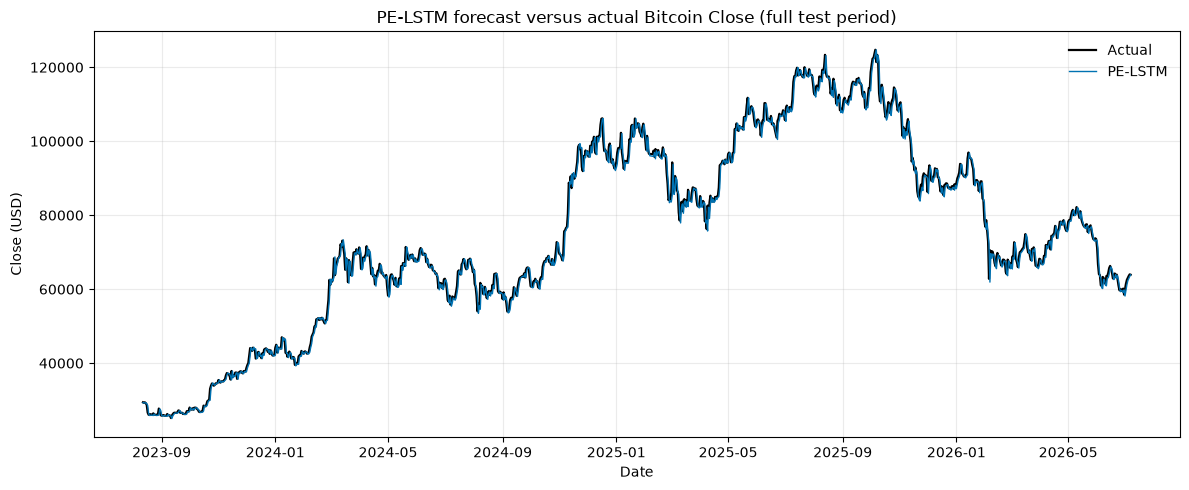

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(validated.index, validated.Actual, color='black', linewidth=1.6, label='Actual')
ax.plot(validated.index, validated.Persistence_Enhanced_LSTM, color='#0072B2', linewidth=1.0, label='PE-LSTM')
ax.set(title='PE-LSTM forecast versus actual Bitcoin Close (full test period)', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

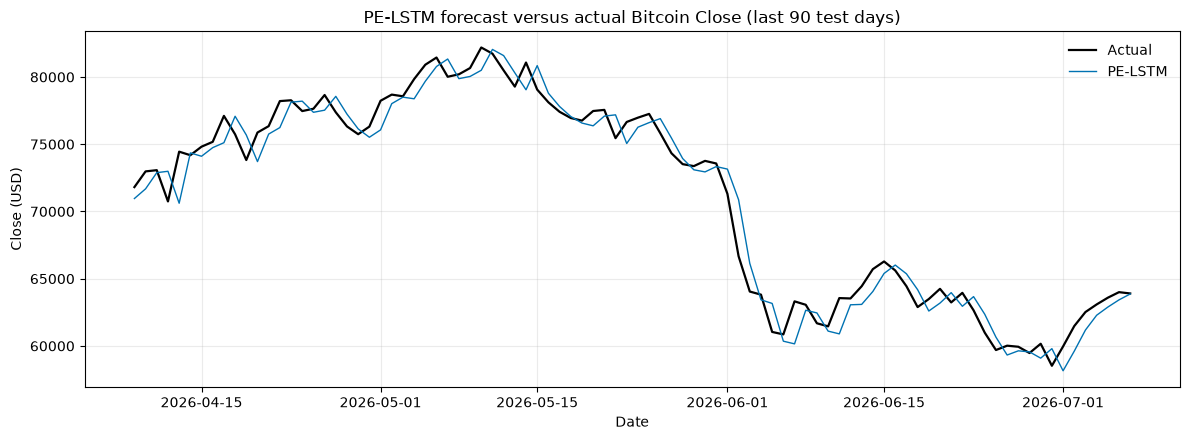

In [9]:
window = validated.index[-90:]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(window, validated.Actual.loc[window], color='black', linewidth=1.6, label='Actual')
ax.plot(window, validated.Persistence_Enhanced_LSTM.loc[window], color='#0072B2', linewidth=1.0, label='PE-LSTM')
ax.set(title='PE-LSTM forecast versus actual Bitcoin Close (last 90 test days)', xlabel='Date', ylabel='Close (USD)')
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 4.4 Residual Analysis

Residuals are defined consistently as `e_t = y_t - y_hat_t` (Actual minus Forecast).

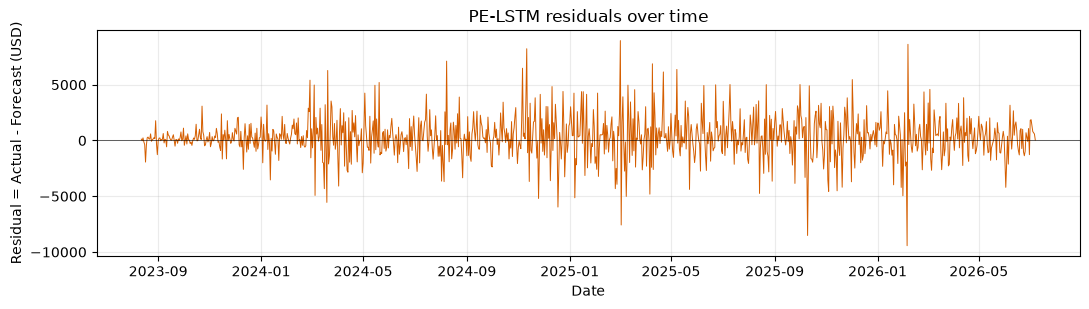

In [10]:
residual = validated.Actual - validated.Persistence_Enhanced_LSTM

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(residual.index, residual, color='#D55E00', linewidth=0.7)
ax.axhline(0, color='black', linewidth=0.7, alpha=0.6)
ax.set(title='PE-LSTM residuals over time', xlabel='Date', ylabel='Residual = Actual - Forecast (USD)')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

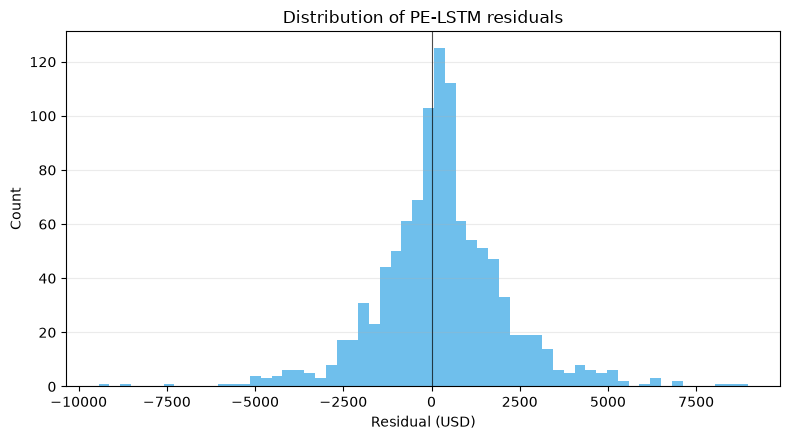

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(residual, bins=60, color='#56B4E9', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.7)
ax.set(title='Distribution of PE-LSTM residuals', xlabel='Residual (USD)', ylabel='Count')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

In [12]:
residual_summary = pd.Series({
    'Mean': residual.mean(), 'Median': residual.median(), 'Std Dev': residual.std(),
    'Min': residual.min(), 'Max': residual.max(), 'MAE': residual.abs().mean(),
}, name='Persistence-Enhanced Log-Return LSTM').to_frame().T.round(3)
residual_summary

,Mean,Median,Std Dev,Min,Max,MAE
Persistence-Enhanced Log-Return LSTM,282.82,230.897,1860.586,-9433.774,8956.705,1321.365


The residual mean (approximately +\$283) is positive and visibly larger than Naive's or SES's residual means from Notebook 02 (both under +\$40) relative to a similar dispersion (std approximately \$1,861) - a mild but real systematic bias in this specific run, with the model tending to under-forecast slightly more often than the simplest benchmarks do. The largest absolute residuals cluster in early 2025 and early 2026, coinciding with sharp short-horizon price movements, consistent with the general pattern that large errors accompany large actual moves rather than occurring uniformly at random. Residual dispersion does not show an obvious trend over the test window. This is a visual/numerical characterisation only; residuals are not formally tested for whiteness here - that belongs to Notebook 11.

# 5. Reproducibility Record

In [13]:
reproducibility_record = pd.DataFrame({
    'Evidence': [
        42,
        'TensorFlow / Keras',
        'Not verified in this notebook (recorded historically in docs/bitcoin_reproducibility.md as TensorFlow 2.21.0)',
        'Yes',
        'Yes',
        'Recorded historically as Python 3.13.2, Windows x86-64',
        'CPU-only',
        'Yes -- three fresh-kernel reruns (repository Git history)',
        '0 (bit-identical across those three historically verified runs)',
        'No',
        'Yes',
        'Yes',
    ],
}, index=[
    'Random seed', 'Framework', 'Framework version', 'Deterministic execution requested',
    'shuffle=False', 'Platform', 'CPU/GPU', 'Fresh-kernel reruns performed historically',
    'Reported maximum run-to-run difference', 'Independent rerun forecast vectors preserved',
    'Final frozen forecast preserved', 'Forecast SHA-256 protected',
])
reproducibility_record

,Evidence
Random seed,42
Framework,TensorFlow / Keras
Framework version,Not verified in this notebook (recorded histor...
Deterministic execution requested,Yes
shuffle=False,Yes
Platform,"Recorded historically as Python 3.13.2, Window..."
CPU/GPU,CPU-only
Fresh-kernel reruns performed historically,Yes -- three fresh-kernel reruns (repository G...
Reported maximum run-to-run difference,0 (bit-identical across those three historical...
Independent rerun forecast vectors preserved,No


"Historically verified" (the three-fresh-kernel-run check) is distinct from "independently reproducible from preserved run artifacts": the individual run vectors from those three checks were not kept as separate files, so this notebook cannot re-demonstrate bit-identity from stored artifacts - it can only cite the historical verification record and the single frozen vector that resulted from it. No determinism figure is fabricated by plotting one vector multiple times.

# 6. Development Provenance

Earlier raw-price LSTM formulations existed during development and are classified as `SUPERSEDED / EXPLORATORY`. The final log-return, persistence-anchored formulation (Sections 3.1-3.3) replaced them because Notebook 01 demonstrates that raw daily Close is strongly non-stationary, while a model trained directly on that non-stationary price scale is far more prone to range-compression and lag failures.

**HISTORICAL DEVELOPMENT EVIDENCE - NOT PART OF FINAL RANKING**

A verified historical metric survives in this repository's Git history for the original raw-price LSTM, retained there as an explicit pedagogical failure case. It is not reproduced or rerun here.

In [14]:
historical_provenance = pd.DataFrame([
    {'Variant': 'Raw-price LSTM (original, archived run)', 'Target': 'Raw daily Close level', 'Status': 'SUPERSEDED / EXPLORATORY',
     'Verified historical MAE': 17714.415711, 'Verified historical RMSE': 20600.026412,
     'Verified historical MAPE': 21.033946, 'Verified historical sMAPE': 23.929986},
]).set_index('Variant')
historical_provenance

,Target,Status,Verified historical MAE,Verified historical RMSE,Verified historical MAPE,Verified historical sMAPE
Variant,,,,,,
"Raw-price LSTM (original, archived run)",Raw daily Close level,SUPERSEDED / EXPLORATORY,17714.415711,20600.026412,21.033946,23.929986


This variant is excluded from every final table, figure, Trust Score, and inference test in this project. An additional exploratory scaffold (`03b_LSTM_Improved.ipynb`) referenced earlier in project history was later removed from the repository entirely - it was unexecuted and had no artifact dependencies - so no further historical variant is reproducible here.

# 7. Key Findings

- The PE Log-Return LSTM produces a stable, finite, fully-aligned one-step forecast across all 1,061 test days, with no missing or nonfinite predictions.
- It does not beat the Naive persistence baseline in observed MAE or RMSE: its MAE is approximately 2.40% higher than Naive's, and its RMSE (1881.09) is higher than Naive's, SES's, ARIMA's, and the additive-trend model's from Notebook 02.
- It remains well ahead of the weakest classical system: PE-LSTM's RMSE and MAE are both substantially lower than the 7-Day Moving Average's. It does **not** trail every classical model from Notebook 02 - it trails four of the five (Naive, SES, ARIMA, additive-trend) but beats the fifth (MA7).
- Added recurrent-model complexity does not translate into superior point accuracy for this Bitcoin task under this protocol - this is important evidence for the project's broader hypothesis that complexity does not guarantee trustworthy forecasting performance.
- The return-based, persistence-anchored formulation used here is substantially more defensible than the historical raw-price formulation (Section 6): it directly addresses the non-stationary level representation identified in Notebook 01, rather than training a sequence model on a series whose scale changed by roughly four orders of magnitude.

# 8. Limitations

- Evidence covers one Bitcoin asset (BTC/USD) and one frozen final test period (1,061 days, 2023-08-12 to 2026-07-07).
- Evaluation is one-step-ahead only; no longer-horizon Bitcoin claim is made here.
- A single 30-day input window length is used; no systematic lookback sensitivity analysis is reported.
- No comprehensive hyperparameter optimisation (units, batch size, epoch budget, learning rate) is documented in the repository - the configuration in Section 3.2 reflects the implementation as built, not a tuned search.
- Epoch-level training and validation loss history was not preserved for the authoritative run (Section 3.5).
- Independent fresh-kernel rerun forecast vectors were not preserved separately; only the historical verification record and the single frozen vector remain (Section 5).
- A single deterministic run does not quantify seed-to-seed model uncertainty - determinism guarantees the same run always reproduces the same output, not that a different seed would produce a similar one.
- Because the forecast is persistence-anchored (Section 3.3), its performance should be interpreted relative to the strong persistence baseline established in Notebook 02, not in isolation.
- The architecture is a domain-specific configuration built for this task, not a claim of a universal or extensively benchmarked LSTM formulation.

# 9. Next Notebook

Next: `04_Bitcoin_PE_Transformer.ipynb`

Notebook 04 tests whether a Transformer-style sequence model, using the same broader return-based, persistence-aware design philosophy, improves on the LSTM or reveals similar complexity-versus-accuracy limitations.